# PS-S5E12: LightGBM

This notebook tackles the [**Playground Series – Season 5, Episode 12: Diabetes Prediction Challenge**](https://www.kaggle.com/competitions/playground-series-s5e12), a competition focused on aiding medical diagnosis: predict if a patient will be diagnosed with diabetes.  The goal is to develop a model that can accurately predict whether a patient will be diagnosed with diabetes, based on a set of medical and demographic features.

## Introduction

**LightGBM** distinguishes itself with a "leaf-wise" (best-first) tree growth strategy, contrasting with the traditional "level-wise" (depth-wise) approach used by XGBoost. This allows it to converge faster and often capture more complex, non-linear dependencies in physiological data. It handles missing values internally and is highly optimized for memory efficiency and training speed. While LightGBM has native support for categorical features, we will utilize our refined feature engineering pipeline to ensure robust inputs.

The notebook is one of a number of notebooks that explore various models to address this challenge, with the ultimate goal of ensembling these diverse learners. The EDA for this dataset was performed in this notebook: [**PS-S5E12: EDA**](https://www.kaggle.com/code/stephentarter/ps-s5e12-eda).

## Install Needed Packages

In [1]:
%load_ext autoreload
%autoreload 2
    
%pip install --no-binary lightgbm --config-settings=cmake.define.USE_CUDA=ON lightgbm


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [24]:
import os
import sys
import math
import random
import warnings
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# --- Third-party
import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler # Import this
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt
import seaborn as sns

from diabetes_preprocessing import FeatureFactory
from model_visualizer import ModelVisualizer
from experiment_setup import ExperimentSetup

# --- Notebook settings
warnings.filterwarnings('ignore')

%matplotlib inline

In [3]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# The target feature
TARGET = 'diagnosed_diabetes'

# Show GPU be utilized in training
USE_GPU = False

# Recursive Feature Elimination should be performed in the pipeline.
PERFORM_RFE = False

# Optuna tuning should be performed in the pipeline
PERFORM_OPTUNA_TUNING = False

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [4]:
training_df = helper.read_training_dataset()

TRAINING DATASET

   id  age  alcohol_consumption_per_week  physical_activity_minutes_per_week  \
0   0   31                             1                                  45   
1   1   50                             2                                  73   
2   2   32                             3                                 158   
3   3   54                             3                                  77   
4   4   54                             1                                  55   

   diet_score  sleep_hours_per_day  screen_time_hours_per_day    bmi  \
0       7.700                6.800                      6.100 33.400   
1       5.700                6.500                      5.800 23.800   
2       8.500                7.400                      9.100 24.100   
3       4.600                7.000                      9.200 26.600   
4       5.700                6.200                      5.100 28.800   

   waist_to_hip_ratio  systolic_bp  diastolic_bp  heart_rate  \
0   

## Read and Examine the Test Dataset

In [5]:
test_df = helper.read_test_dataset()

TEST DATASET

       id  age  alcohol_consumption_per_week  \
0  700000   45                             4   
1  700001   35                             1   
2  700002   45                             1   
3  700003   55                             2   
4  700004   77                             2   

   physical_activity_minutes_per_week  diet_score  sleep_hours_per_day  \
0                                 100       4.300                6.800   
1                                  87       3.500                4.600   
2                                  61       7.600                6.800   
3                                  81       7.300                7.300   
4                                  29       7.300                7.600   

   screen_time_hours_per_day    bmi  waist_to_hip_ratio  systolic_bp  \
0                      6.200 25.500               0.840          123   
1                      9.000 28.600               0.880          120   
2                      7.000 28.500 

## Feature Engineering

In [6]:
# Define which strategies to use for the XGBoost model here:
fe_strategies = [
    'drop_id',
    'ordinal_encoding',
    'medical_metrics',
    'clinical_indices',
    'binning',
    'clustering',
    'interactions',
    'ratios',
    'log',
    'polynomials'
]

In [7]:
print('Performing initial feature engineering.')

# Get the target before we start messing with features
y = training_df[TARGET]

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET)

# Fit_transform on training, transform on test
X_full = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

X = X_full.drop(TARGET, axis=1, errors='ignore')

print(f'Old Feature Count: {training_df.shape[1] - 1}')
print(f'New Feature Count: {X.shape[1]}')
print(X.head())

Performing initial feature engineering.
Old Feature Count: 25
New Feature Count: 43
   age  alcohol_consumption_per_week  physical_activity_minutes_per_week  \
0   31                             1                                  45   
1   50                             2                                  73   
2   32                             3                                 158   
3   54                             3                                  77   
4   54                             1                                  55   

   diet_score  sleep_hours_per_day  screen_time_hours_per_day    bmi  \
0       7.700                6.800                      6.100 33.400   
1       5.700                6.500                      5.800 23.800   
2       8.500                7.400                      9.100 24.100   
3       4.600                7.000                      9.200 26.600   
4       5.700                6.200                      5.100 28.800   

   waist_to_hip_ratio  sys

## Recursive Feature Elimination and Optuna Training

This section optionally runs an Optuna trial to determine the best set of hyperscaling parameters.  If training isn't requested, a set of hyperparameters derived from an earlier run is used instead.

If Optuna Tuning was run, Recursive Feature Elimination (RFE) is performed.  This works by training the model, identifying the weakest feature, deleting it, and then re-training. It repeats this process until it finds the exact subset of features that gives the highest Cross-Validation score.

In [8]:
# LightGBM handles CPU parallelism very well, but use 1 job if using GPU to avoid contention
n_jobs = 1 if USE_GPU else -1

if PERFORM_RFE:    
    # Suppress the specific XGBoost warning to clean up the output
    warnings.filterwarnings('ignore', message='.*Falling back to prediction using DMatrix.*')
    
    # Sensible defaults for Feature Selection (RFECV)
    rfe_params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        
        # Speed/Capacity Balance
        'n_estimators': 1000,       # Reduced from 3000 for faster RFECV loops
        'learning_rate': 0.05,      # Standard robust baseline
        
        # Tree Structure (Standard Defaults)
        'num_leaves': 31,           # Approx depth 5 (2^5 = 32)
        'max_depth': -1,            # Let num_leaves handle complexity
        'min_child_samples': 20,    # Standard guard against leaf overfitting
        
        # Stochastic Components (Good for feature diversity)
        'colsample_bytree': 0.8,
        'subsample': 0.8,
        
        # Regularization (Light, just for stability)
        'reg_alpha': 0.1,
        'reg_lambda': 0.1,
        'min_split_gain': 0.0,
        
        # Hardware / System
        'random_state': seed,
        'n_jobs': n_jobs,           # 1 if GPU, -1 if CPU
        'verbosity': -1,
        'device_type': 'gpu' if USE_GPU else 'cpu'
    }
    
    # Setup Model with Best Params
    # We use the exact same params that found the signal in the noise
    clf = lgb.LGBMClassifier(**rfe_params)

    # Convert object columns to 'category' dtype
    X_rfe = X.copy()

    # Identify string/object columns
    cat_cols = X_rfe.select_dtypes(include=['object', 'category']).columns.tolist()
    
    if cat_cols:
        # Use OrdinalEncoder to turn "Female" -> 0, "Male" -> 1
        oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        X_rfe[cat_cols] = oe.fit_transform(X_rfe[cat_cols])
        
        # Ensure they are cast to integer type for XGBoost
        # We cast to 'category' type so XGBoost knows to treat them as discrete
        for col in cat_cols:
            X_rfe[col] = X_rfe[col].astype('category')
 
    # Initialize RFECV
    # step=1: remove 1 feature at a time (most precise)
    # min_features_to_select=10: Don't go below 10 features
    rfecv = RFECV(
        estimator=clf,
        step=1,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=seed),
        scoring='roc_auc',
        min_features_to_select=10,
        n_jobs=n_jobs,
        verbose=0
    )
    
    print('Running Recursive Feature Elimination (this may take 2-3 minutes)...')
    rfecv.fit(X_rfe, y)
    
    # Results
    print(f'Optimal number of features: {rfecv.n_features_}')
    
    # Plot Performance vs Number of Features
    # Note: usage of cv_results_ depends on sklearn version, this is for recent versions
    n_scores = len(rfecv.cv_results_['mean_test_score'])
    plt.figure(figsize=(10, 6))
    plt.xlabel('Number of features selected')
    plt.ylabel('Cross validation score (AUC)')
    plt.plot(
        range(10, 10 + n_scores),
        rfecv.cv_results_['mean_test_score']
    )
    plt.show()

    # Save the selected features for the next step
    optimal_cols = X.columns[rfecv.support_]
else:
    print('Using optimal features derived from an earlier run.')
    optimal_cols = pd.Index([
        'age',
        'alcohol_consumption_per_week',
        'physical_activity_minutes_per_week',
        'diet_score',
        'sleep_hours_per_day',
        'screen_time_hours_per_day',
        'bmi',
        'waist_to_hip_ratio',
        'systolic_bp',
        'diastolic_bp',
        'heart_rate',
        'cholesterol_total',
        'hdl_cholesterol',
        'ldl_cholesterol',
        'triglycerides',
        'family_history_diabetes',
        'hypertension_history',
        'cardiovascular_history', 
        'education_level_ord',
        'income_level_ord',
        'pulse_pressure',
        'mean_arterial_pressure',
        'non_hdl_cholesterol',
        'vai_proxy',
        'lap_proxy',
        'bp_class',
        'age_bmi_interaction',
        'sedentary_ratio',
        'cholesterol_risk_ratio',
        'bp_ratio',
        'whr_bmi_product',
        'triglycerides_log',
        'screen_time_log',
        'age_sq',
        'bmi_sq',
        'cluster_label',
        'gender_Female',
        'ethnicity_Hispanic',
        'ethnicity_Other',
        'ethnicity_White',
        'education_level_Highschool',
        'education_level_Postgraduate',
        'income_level_Middle',
        'smoking_status_Current',
        'smoking_status_Never',
        'employment_status_Employed',
        'employment_status_Retired'
    ])
    
print('\nOptimal Features:')
print(optimal_cols.tolist())

Using optimal features derived from an earlier run.

Optimal Features:
['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'education_level_ord', 'income_level_ord', 'pulse_pressure', 'mean_arterial_pressure', 'non_hdl_cholesterol', 'vai_proxy', 'lap_proxy', 'bp_class', 'age_bmi_interaction', 'sedentary_ratio', 'cholesterol_risk_ratio', 'bp_ratio', 'whr_bmi_product', 'triglycerides_log', 'screen_time_log', 'age_sq', 'bmi_sq', 'cluster_label', 'gender_Female', 'ethnicity_Hispanic', 'ethnicity_Other', 'ethnicity_White', 'education_level_Highschool', 'education_level_Postgraduate', 'income_level_Middle', 'smoking_status_Current', 'smoking_status_Never', 'employment_status_Emp

In [9]:
def objective(trial):
    
    # Suggest Parameters
    param = {
        'n_estimators': 5000,              # Give it room to run, let early stopping cut it
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        
        # Key LightGBM Parameters
        'num_leaves': trial.suggest_int('num_leaves', 20, 255),  # Main complexity control
        'max_depth': trial.suggest_int('max_depth', 6, 15),
        
        'subsample': trial.suggest_float('subsample', 0.5, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.95),
        
        # Regularization
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100), # 'min_data_in_leaf'
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 1.0),   # Equiv to XGB 'gamma'
        
        # Boilerplate
        'objective': 'binary',
        'metric': 'auc',
        'device_type': 'gpu' if USE_GPU else 'cpu',
        'random_state': seed,
        'n_jobs': n_jobs,
        'verbosity': -1
    }
    
    # Ensure optimal_cols is a standard list for filtering
    # (Handling cases where it might be a pandas Index or numpy array)
    cols_to_keep = list(optimal_cols) if not isinstance(optimal_cols, list) else optimal_cols

    # Fast CV (3 Folds is enough for tuning)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
    scores = []
    
    for train_idx, val_idx in skf.split(training_df, y):
        X_train_fold, X_val_fold = training_df.iloc[train_idx], training_df.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
        
        # Create a FeatureFactory for this fold's data
        fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

        X_train_trans = fe_fold.fit_transform(X_train_fold)
        X_val_trans = fe_fold.transform(X_val_fold)
        
        # Filter Columns using 'optimal_cols'
        # We take the intersection to be safe (in case FE dropped a col for some reason)
        final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
        
        X_train_trans = X_train_trans[final_cols]
        X_val_trans = X_val_trans[final_cols]
        
        cat_cols = X_train_trans.select_dtypes(include=['object', 'category']).columns.tolist()
    
        if cat_cols:
            # Use OrdinalEncoder to turn "Female" -> 0, "Male" -> 1
            oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
            X_train_trans[cat_cols] = oe.fit_transform(X_train_trans[cat_cols])
            X_val_trans[cat_cols] = oe.transform(X_val_trans[cat_cols])
            
            # Ensure they are cast to integer type for XGBoost
            # We cast to 'category' type so XGBoost knows to treat them as discrete
            for col in cat_cols:
                X_train_trans[col] = X_train_trans[col].astype('category')
                X_val_trans[col] = X_val_trans[col].astype('category')
            
        model = lgb.LGBMClassifier(**param)
        
        model.fit(
            X_train_trans, y_train_fold,
            eval_set=[(X_val_trans, y_val_fold)],
            eval_metric='auc',
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )
        
        # Predict
        preds = model.predict_proba(X_val_trans)[:, 1]
        score = roc_auc_score(y_val_fold, preds)
        scores.append(score)

    return np.mean(scores)

if PERFORM_OPTUNA_TUNING:
    # Run Optimization
    sampler = TPESampler(seed=seed)
    
    study = optuna.create_study(
        study_name='lgb_diabetes_prediction_optuna', 
        direction='maximize',
        sampler=sampler
    )
    study.optimize(objective, n_trials=40, show_progress_bar=True)

    print('Best Params:', study.best_params)
    print('Best AUC:', study.best_value)

    best_params = study.best_params
else:
    # Values from earlier tuning
    best_params = {
        'learning_rate': 0.023139864883776343,
        'num_leaves': 36,
        'max_depth': 13,
        'subsample': 0.855957668817888,
        'colsample_bytree': 0.6199076460762318,
        'min_child_samples': 79,
        'reg_alpha': 9.082749462483818,
        'reg_lambda': 0.5733074915391424,
        'min_split_gain': 0.5095237550000878
    }

[I 2025-12-08 16:00:27,682] A new study created in memory with name: lgb_diabetes_prediction_optuna


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2025-12-08 16:05:49,420] Trial 0 finished with value: 0.7266081384683553 and parameters: {'learning_rate': 0.027602609060648257, 'num_leaves': 73, 'max_depth': 15, 'subsample': 0.838563141577915, 'colsample_bytree': 0.6389391005441778, 'min_child_samples': 79, 'reg_alpha': 9.746437376742904, 'reg_lambda': 0.45624196832363745, 'min_split_gain': 0.5128872711650283}. Best is trial 0 with value: 0.7266081384683553.
[I 2025-12-08 16:14:27,347] Trial 1 finished with value: 0.7250754631943436 and parameters: {'learning_rate': 0.015426717383914814, 'num_leaves': 160, 'max_depth': 11, 'subsample': 0.7358433940740137, 'colsample_bytree': 0.8153833741375588, 'min_child_samples': 11, 'reg_alpha': 1.454762191529649, 'reg_lambda': 0.35382830316192654, 'min_split_gain': 0.4431703673877083}. Best is trial 0 with value: 0.7266081384683553.
[I 2025-12-08 16:24:57,685] Trial 2 finished with value: 0.7254999433656488 and parameters: {'learning_rate': 0.01630952768677333, 'num_leaves': 78, 'max_depth': 

## Model Training

In [17]:
# Cross-Validation Training Loop

lgb_tuned_params = {
    **best_params,
    'n_estimators': 6000,
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'n_jobs': n_jobs,
    'random_state': seed,
    'early_stopping_rounds': 50,
    'device_type': 'gpu' if USE_GPU else 'cpu',
    'verbosity': -1
}

# Storage for plotting later
eval_results = []
models = []

# Arrays to store results
oof_preds = np.zeros(len(X))     # Out-of-Fold predictions (for blending later)
test_preds = np.zeros(len(test_df)) # Average test predictions

n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

print(f'\nStarting LightGBM Training ({n_folds} Folds)...')

for fold, (train_idx, val_idx) in enumerate(skf.split(training_df, y)):
    X_train_fold, y_train_fold = training_df.iloc[train_idx], y.iloc[train_idx]
    X_val_fold, y_val_fold = training_df.iloc[val_idx], y.iloc[val_idx]
    
    # Create a FeatureFactory for this fold's data
    fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

    X_train_trans = fe_fold.fit_transform(X_train_fold)
    X_val_trans = fe_fold.transform(X_val_fold)
    X_test_trans = fe_fold.transform(test_df)

    cat_cols = X_train_trans.select_dtypes(include=['object', 'category']).columns.tolist()

    if cat_cols:
        # Use OrdinalEncoder to turn "Female" -> 0, "Male" -> 1
        oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        X_train_trans[cat_cols] = oe.fit_transform(X_train_trans[cat_cols])
        X_val_trans[cat_cols] = oe.transform(X_val_trans[cat_cols])
        X_test_trans[cat_cols] = oe.transform(X_test_trans[cat_cols])

        # Ensure they are cast to integer type for XGBoost
        # We cast to 'category' type so XGBoost knows to treat them as discrete
        for col in cat_cols:
            X_train_trans[col] = X_train_trans[col].astype('category')
            X_val_trans[col] = X_val_trans[col].astype('category')
            X_test_trans[col] = X_test_trans[col].astype('category')

    # Transform Data)
    # Note: We are fitting the preprocessor every fold. 
    model = lgb.LGBMClassifier(**lgb_tuned_params)
    
    # Train Model
    # The pipeline will call feature_factory.fit_transform(X_train)
    # and then pass that result to xgb.fit()
    model.fit(
        X_train_trans, y_train_fold,
        eval_set=[(X_train_trans, y_train_fold), (X_val_trans, y_val_fold)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=100)
        ]
    )
        
    # Store history for this fold
    eval_results.append(model.evals_result_)
    models.append(model)
    
    # Predict Validation Set
    # [:, 1] grabs the probability of class 1 (Diabetes)
    val_probs = model.predict_proba(X_val_trans, num_iteration=model.best_iteration_)[:, 1]
    oof_preds[val_idx] = val_probs
    
    # Score
    score = roc_auc_score(y_val_fold, val_probs)
    print(f'Fold {fold+1} AUC: {score:.5f} (Best Iteration: {model.best_iteration_})')
    
    # Predict Test Set (Accumulate for averaging)
    test_probs = model.predict_proba(X_test_trans, num_iteration=model.best_iteration_)[:, 1]
    test_preds += test_probs / n_folds

# Evaluation

overall_auc = roc_auc_score(y, oof_preds)
print(f'\nOverall OOF AUC: {overall_auc:.5f}')


Starting LightGBM Training (5 Folds)...
[100]	training's auc: 0.712403	valid_1's auc: 0.710557
[200]	training's auc: 0.720649	valid_1's auc: 0.718297
[300]	training's auc: 0.724607	valid_1's auc: 0.721411
[400]	training's auc: 0.727355	valid_1's auc: 0.723171
[500]	training's auc: 0.729541	valid_1's auc: 0.724316
[600]	training's auc: 0.73138	valid_1's auc: 0.724958
[700]	training's auc: 0.733131	valid_1's auc: 0.725618
[800]	training's auc: 0.734672	valid_1's auc: 0.726079
[900]	training's auc: 0.736124	valid_1's auc: 0.726466
[1000]	training's auc: 0.737455	valid_1's auc: 0.726713
[1100]	training's auc: 0.738714	valid_1's auc: 0.726888
[1200]	training's auc: 0.739966	valid_1's auc: 0.727059
[1300]	training's auc: 0.741152	valid_1's auc: 0.727122
[1400]	training's auc: 0.742424	valid_1's auc: 0.727288
[1500]	training's auc: 0.743564	valid_1's auc: 0.727387
[1600]	training's auc: 0.744702	valid_1's auc: 0.72751
[1700]	training's auc: 0.745852	valid_1's auc: 0.727579
Fold 1 AUC: 0.7275

## Visualize the Quality of Training

It is standard practice to visualize Learning Curves (to spot overfitting/underfitting) and the ROC Curve (to check classification performance).

### Learning Curves (Train vs. Validation AUC)

**Definition**  
This graph plots the model's performance (AUC) on the y-axis against the number of boosting rounds (iterations) on the x-axis. It displays two lines:
*   **Blue (Train):** How well the model learned the data it has already seen.
*   **Red (Validation):** How well the model generalizes to new data it hasn't seen.

**Interpretation**  
This graph is fairly easy to interpret, and is a powerful indicator of how the model is likely to perform on new data.
*   **Ideal:** Both lines go up steeply and plateau. The Blue line is slightly higher than the Red line, but the gap is stable.
*   **Overfitting:** The Blue line keeps going up (approaching 1.0), but the Red line flattens out early or starts dropping. The "gap" between them widens significantly.
*   **Underfitting:** Both lines flatten out very early at a low score. The model is too simple to learn the patterns.

**Actions for Overfitting**  
If the Training score is 0.95 but the validation score is 0.72, the  are overfitting.
1.  **Restrict Depth:** Reduce `max_depth` (e.g., from 6 to 3 or 4). This forces the model to learn simpler, more general rules.
2.  **Add Randomness:** Lower `subsample` and `colsample_bytree` (e.g., to 0.6). This prevents the model from relying too heavily on specific rows or features.
3.  **Increase Regularization:** Increase `reg_alpha` (L1) or `reg_lambda` (L2). This penalizes the model for becoming too complex.
4.  **Increase `min_child_weight`:** This prevents the tree from creating leaves that only apply to a tiny handful of patients (noise).

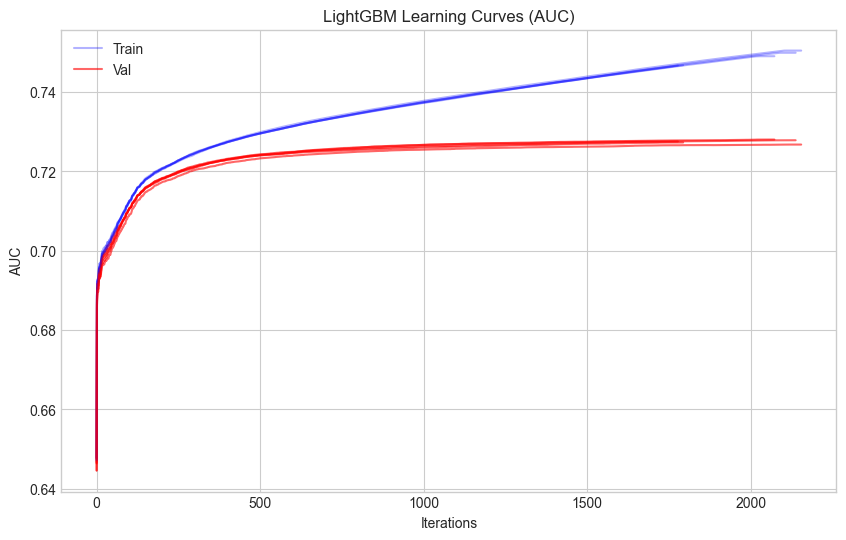

In [25]:
mviz = ModelVisualizer(model_name='LightGBM')

mviz.plot_learning_curves(eval_results)

### Feature Importance (Gain)

This chart ranks features by how much they improved the model's accuracy (reduced the loss function) whenever they were used in a split.

**Interpretation**  
*   **High Gain:** These are the "Signal" features. The model relies on them heavily.
*   **Low/Zero Gain:** These features were rarely useful. The model mostly ignored them.

**What if engineered features aren't at the top?**  
*   **Don't Panic:** It's okay if raw features like Glucose or BMI are still top. They are strong predictors!
*   **Check Correlations:** If BMI is #1 and your engineered BMI\_Ratio is #50, they might be highly correlated, and the model just chose the simpler one. This is fine.
*   **Re-evaluate:** If an engineered feature is at the very bottom (0 importance), it failed. The hypothesis behind it (e.g., "Age \* Height") likely has no biological relevance.

**What to do with Low Performing Features**  
*   **Zero Importance:** **Drop them.** They add computational cost and noise without adding value.
*   **Low Importance:**  
    *   **Try Dropping:** Sometimes removing "noise" features helps the model focus on the signal (increases score).
  
    *   **Combine Them:** If SkinThickness is weak on its own, try creating an interaction like Insulin / SkinThickness. Sometimes two weak features make one strong feature.

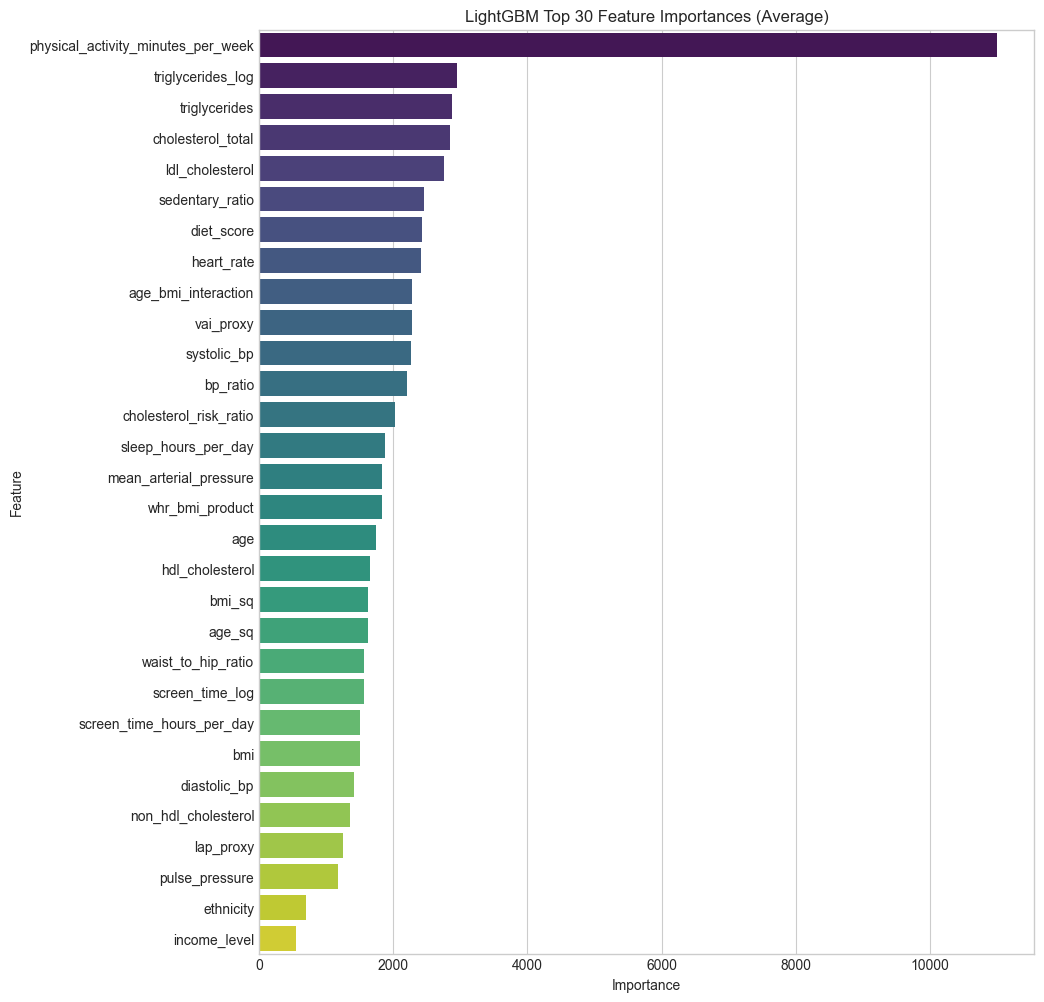

In [26]:
mviz.plot_feature_importance(models, show_values=True)

### ROC Curve (Receiver Operating Characteristic)

A plot of the **True Positive Rate** (Sensitivity) vs. the **False Positive Rate** (1 - Specificity) at every possible probability threshold (0% to 100%).

**Interpretation**  
*   **Top-Left Corner:** The perfect model. It catches 100% of diabetes cases with 0 false alarms.
*   **Diagonal Line:** Random guessing (AUC = 0.5).
*   **The Curve:** Shows the trade-off. To catch more diabetes cases (move up), we inevitably accept more false alarms (move right).
    

**What else can ROC be used for?**  
*   **Threshold Tuning:** The model outputs a probability (e.g., 0.35). Is that a "Yes" or a "No"?
    *   If this is a **Pre-Screening App** (high sensitivity needed), we pick a point high on the Y-axis (e.g., threshold 0.2), accepting that we'll flag some healthy people.
    *   If this is for **Surgery** (high precision needed), we pick a point far left on the X-axis (e.g., threshold 0.8), ensuring we only operate when very certain.
*   **Model Comparison:** In the upcoming "Model Blending/Stacking" notebook, we can plot the curves for XGBoost, CatBoost, and LightGBM on one graph. If the curves cross, one model might be better for high-sensitivity tasks while the other is better for high-precision tasks, even if their AUC is similar.

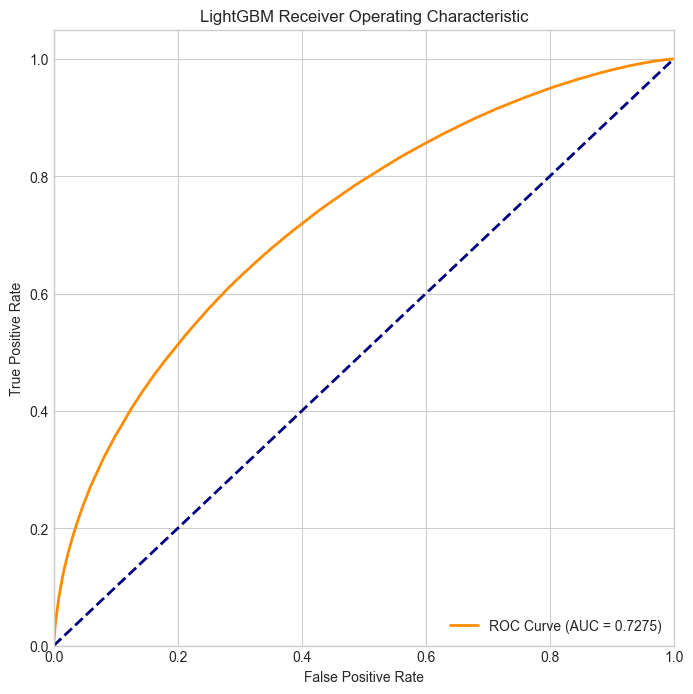

In [27]:
mviz.plot_roc_curve(y, oof_preds)

## Prepare Submission

In [21]:
submission_df = helper.read_sample_submission_dataset()
submission_df[TARGET] = test_preds

print('SUBMISSION')
print('==========')

print(submission_df.head(10))

SAMPLE SUBMISSION
       id  diagnosed_diabetes
0  700000               0.483
1  700001               0.688
2  700002               0.779
3  700003               0.391
4  700004               0.924
5  700005               0.651
6  700006               0.722
7  700007               0.920
8  700008               0.583
9  700009               0.853


In [22]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Predictions

The OOF and test predictions are saved so that they may be used for comparison of performance differences between the various models, or by a notebook exploring blending the predictions of the models using some of the tools and techniques outline by Tilii in his excellent [For the (recovering) blind blending addicts](https://www.kaggle.com/competitions/playground-series-s5e12/discussion/651787).

In [23]:
# Ensure directory exists
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True) 

# Save OOF predictions and raw Test predictions.
# We will load these files in a separate "Blending Notebook".
oof_df = pd.DataFrame({'id': training_df.index, 'pred_lgb': oof_preds, 'target': y})
oof_df.to_csv(f'{output_dir}/lgb_oof_preds.csv', index=False)

test_pred_df = pd.DataFrame({'id': test_df.index, 'pred_lgb': test_preds})
test_pred_df.to_csv(f'{output_dir}/lgb_test_preds.csv', index=False)

print(f'Saved for Blending: {output_dir}/lgb_oof_preds.csv, {output_dir}/lgb_test_preds.csv')

Saved for Blending: predictions/lgb_oof_preds.csv, predictions/lgb_test_preds.csv
